# Presidents. Classification based on CLS token embeddings + smoothing

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from sklearn.neighbors import KernelDensity
from sklearn.pipeline import Pipeline
from scipy.signal import medfilt

from rital_nlp_project.common.utils import load_clean_data, load_pres
from rital_nlp_project.common.notebook_utils import init_notebook
from rital_nlp_project.common.models.models_eval import eval_pipeline_movies, eval_pipeline_presidents

from rital_nlp_project.presidents.models import SmoothedProbaClassifier, smooth_gauss
from rital_nlp_project.presidents.models_utils import *
from rital_nlp_project.presidents.utils import load_with_numbers

init_notebook()

In [2]:
texts_pres, classes_pres = load_clean_data("../Dataset/clean/presidents_clean_bert.parquet")
embeds = np.load("../Dataset/embeddings/pres_camembert_large.npy") 
#df_ids = load_with_numbers("../Dataset/presidents.utf8")
#df_ids["class"] = classes_pres
classes_pres = np.where(classes_pres == -1, 1, 0)

In [3]:
def print_all_metrics(true, probs):
    preds = np.where(probs>0.5, 1, 0)

    print(f"Accuracy  : {accuracy_score(true, preds):.2f}")
    print(f"Precision : {precision_score(true, preds):.2f}")
    print(f"Recall    : {recall_score(true, preds):.2f}")
    print(f"F1-score  : {f1_score(true, preds):.2f}")
    print(f"ROC AUC   : {roc_auc_score(true, probs):.2f}")
    print(f"PR AUC    : {average_precision_score(true, probs):.2f}")

### Without feature engineering

In [16]:
pipe = Pipeline([
    ("vect", None),
    ("classifier", LogisticRegression(max_iter=1000, class_weight=None))
])
res = eval_pipeline_presidents(pipe, embeds, classes_pres, cv=False, split=True)
res

Pipeline(steps=[('vect', None),
                ('classifier', LogisticRegression(max_iter=1000))])


{'accuracy': 0.9030741095532526,
 'f1': 0.3867768595041322,
 'recall': 0.30180567497850386,
 'precision': 0.5383435582822086,
 'roc_auc': 0.82123034520453,
 'pr_auc': 0.4257305624435521,
 'train_vocab_size': None}

In [ ]:
pipe = Pipeline([
    ("vect", None),
    ("classifier", LogisticRegression(max_iter=1000, class_weight={0:1, 1:2}))
])
res = eval_pipeline_presidents(pipe, embeds, classes_pres, cv=False, split=True)

Pipeline(steps=[('vect', None),
                ('classifier',
                 LogisticRegression(class_weight={0: 1, 1: 2}, max_iter=1000))])


{'accuracy': 0.8776452146651572,
 'f1': 0.42723196086424786,
 'recall': 0.45055889939810834,
 'precision': 0.4062015503875969,
 'roc_auc': 0.8215777826657867,
 'pr_auc': 0.422999767447632,
 'train_vocab_size': None}

### Train/test split

In [17]:
X_train, X_test, y_train, y_test = split_fn(embeds, classes_pres)

In [18]:
# Feature engineering
X_train_concat, X_test_concat, y_train_concat, y_test_concat = expand_train_test(X_train, X_test, y_train, y_test, n=1)

In [ ]:
# Without FE 
model = LogisticRegression(max_iter=1000, class_weight={0:1, 1:2})
model.fit(X_train, y_train)
probs_base = model.predict_proba(X_test)[:, 1]

In [12]:
model = LogisticRegression(max_iter=1000, class_weight={0:1, 1:2})
model.fit(X_train_concat, y_train_concat)

probs = model.predict_proba(X_test_concat)[:, 1]
print_all_metrics(y_test_concat, probs)

Accuracy  : 0.89
Precision : 0.46
Recall    : 0.63
F1-score  : 0.53
ROC AUC   : 0.89
PR AUC    : 0.56


In [20]:
# Use class weight=None afterwards
model = LogisticRegression(max_iter=1000, class_weight=None)
model.fit(X_train_concat, y_train_concat)

probs = model.predict_proba(X_test_concat)[:, 1]
print_all_metrics(y_test_concat, probs)

Accuracy  : 0.91
Precision : 0.54
Recall    : 0.54
F1-score  : 0.54
ROC AUC   : 0.89
PR AUC    : 0.57


In [21]:
probas = model.predict_proba(X_test_concat)

probas_smooth_gauss = smooth_gauss(model.predict_proba(X_test_concat), sigma=1)
probas_smooth_gauss = smooth_gauss(model.predict_proba(X_test_concat), sigma=4)
 
# pred = probas.argmax(axis=1)

df = pd.DataFrame(data={
    "true":y_test_concat,
    "prob_smooth_gauss_1":smooth_gauss(model.predict_proba(X_test_concat), sigma=1)[:, 1],
    "prob_smooth_gauss_4":smooth_gauss(model.predict_proba(X_test_concat), sigma=4)[:, 1],
    "prob_median":medfilt(model.predict_proba(X_test_concat)[:, 1], kernel_size=5),
    "prob_raw":probas[:, 1]
})
df

,true,prob_smooth_gauss_1,prob_smooth_gauss_4,prob_median,prob_raw
0,0,0.139232,0.066116,0.000778,0.216316
1,0,0.067665,0.064325,0.002238,0.000778
2,0,0.027281,0.060929,0.011394,0.002238
3,0,0.033982,0.056200,0.011394,0.050267
4,0,0.060642,0.050536,0.021542,0.011394
...,...,...,...,...,...
11476,0,0.026743,0.025286,0.006957,0.006698
11477,0,0.010579,0.022591,0.006957,0.006957
11478,0,0.008235,0.020189,0.006698,0.003214
11479,0,0.009370,0.018390,0.003214,0.018138


Text(0, 0.5, 'Probability')

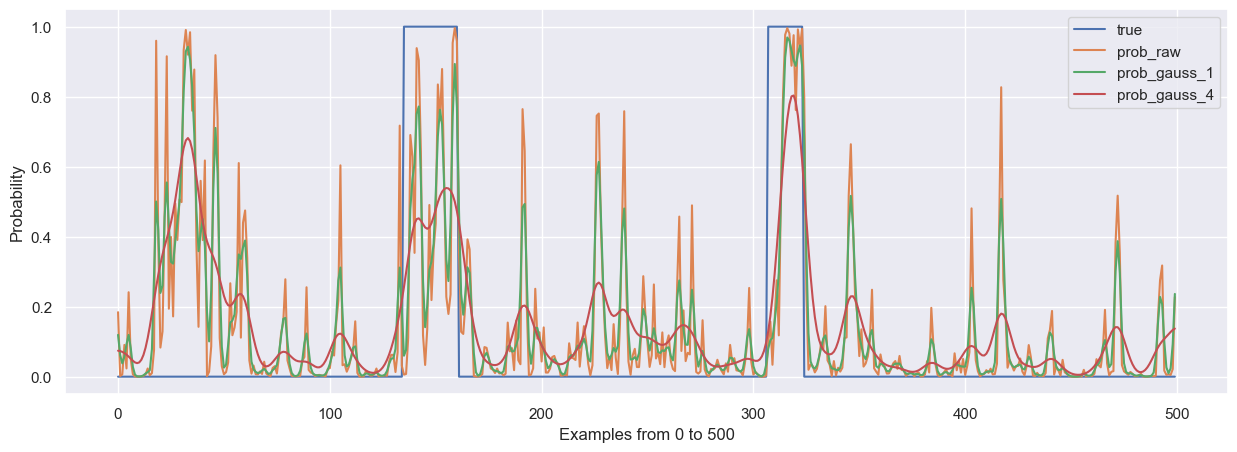

In [8]:
fig=plt.figure(figsize=(15, 5))

mn, mx = 0, 500
sns.lineplot(df["true"].iloc[mn:mx], label="true")
sns.lineplot(df["prob_raw"].iloc[mn:mx], label="prob_raw")
sns.lineplot(df["prob_smooth_gauss_1"].iloc[mn:mx], label="prob_gauss_1")
sns.lineplot(df["prob_smooth_gauss_4"].iloc[mn:mx], label="prob_gauss_4")
plt.legend() 
plt.xlabel(f"Examples from {mn} to {mx}")
plt.ylabel("Probability")
#fig.savefig("plots/cls_token_prob_gauss.pdf", bbox_inches="tight")

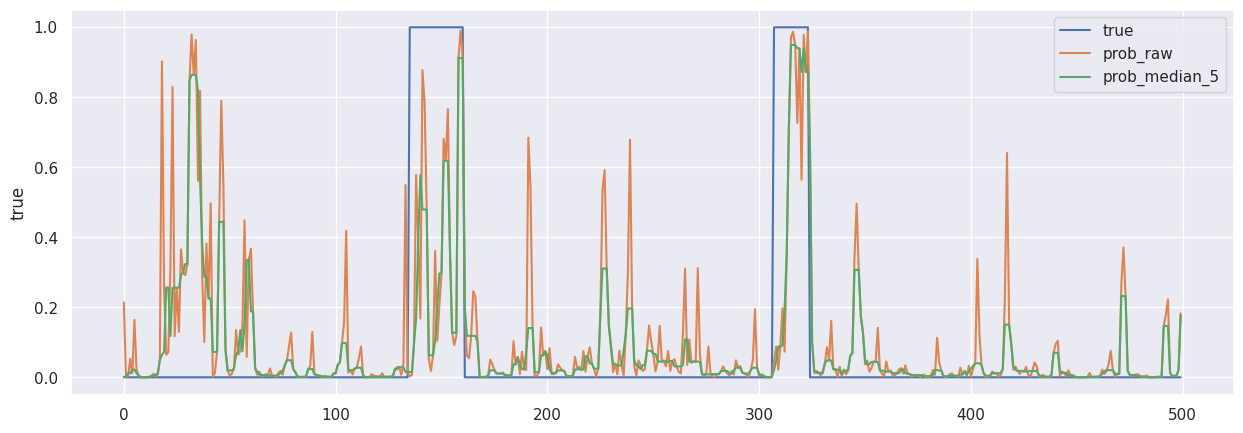

In [ ]:
fig=plt.figure(figsize=(15, 5))

mn, mx = 0, 500
sns.lineplot(df["true"].iloc[mn:mx], label="true")
sns.lineplot(df["prob_raw"].iloc[mn:mx], label="prob_raw")
sns.lineplot(df["prob_median"].iloc[mn:mx], label="prob_median_5")
plt.xlabel(f"Examples from {mn} to {mx}")
plt.ylabel("Probability")
fig.savefig("plots/cls_token_prob_median.pdf", bbox_inches="tight")

In [22]:
unique_class, lengths = get_seq_len(y_train)

kde_0 = KernelDensity(kernel='gaussian', bandwidth=1.0)
kde_1 = KernelDensity(kernel='gaussian', bandwidth=1.0)
len_0 = lengths[unique_class == 0]
len_1 = lengths[unique_class == 1]

kde_0.fit(len_0.reshape(-1, 1))
kde_1.fit(len_1.reshape(-1, 1))

D_max_0 = len_0.max()
D_max_1 = len_1.max()

D_max = [D_max_0, D_max_1]
kde = [kde_0, kde_1]

log_probs = model.predict_log_proba(X_test_concat)
S = get_scores_smooth_duration(log_probs, D_max, kde)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

Text(0, 0.5, 'Probability')

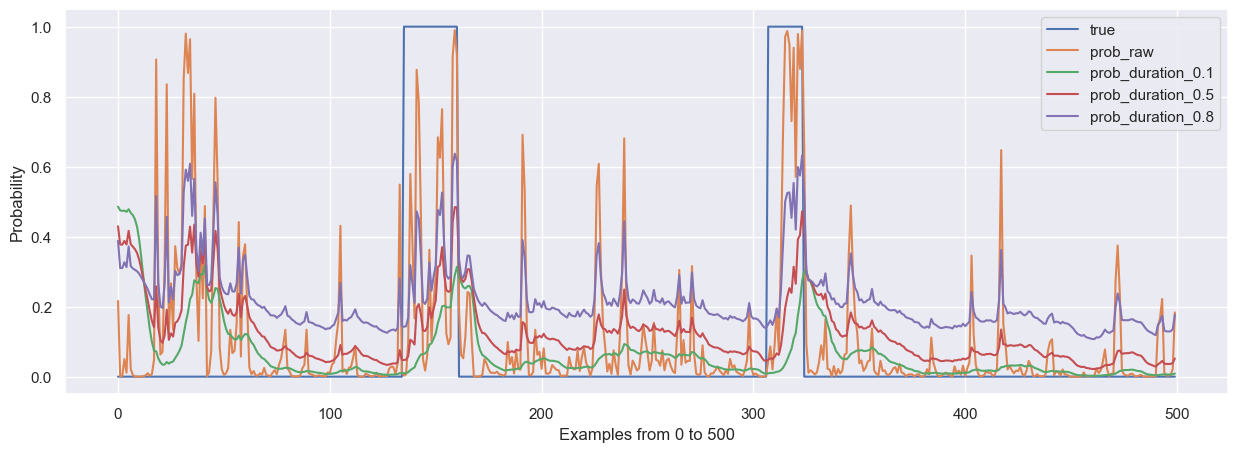

In [24]:
alpha = 0.5
df["prob_duration_0.5"] = smooth_prob_duration(probas, 0.5, S)[:, 1]
df["prob_duration_0.1"] = smooth_prob_duration(probas, 0.1, S)[:, 1]
df["prob_duration_0.8"] = smooth_prob_duration(probas, 0.8, S)[:, 1]


fig=plt.figure(figsize=(15, 5))
mn, mx = 0, 500
sns.lineplot(df["true"].iloc[mn:mx], label="true")
sns.lineplot(df["prob_raw"].iloc[mn:mx], label="prob_raw")
sns.lineplot(df["prob_duration_0.1"].iloc[mn:mx], label="prob_duration_0.1")
sns.lineplot(df["prob_duration_0.5"].iloc[mn:mx], label="prob_duration_0.5")
sns.lineplot(df["prob_duration_0.8"].iloc[mn:mx], label="prob_duration_0.8")

plt.xlabel(f"Examples from {mn} to {mx}")
plt.ylabel("Probability")
#fig.savefig("plots/cls_token_prob_duration.pdf", bbox_inches="tight")

prob_raw
prob_smooth_gauss_4
prob_median
prob_duration_0.5


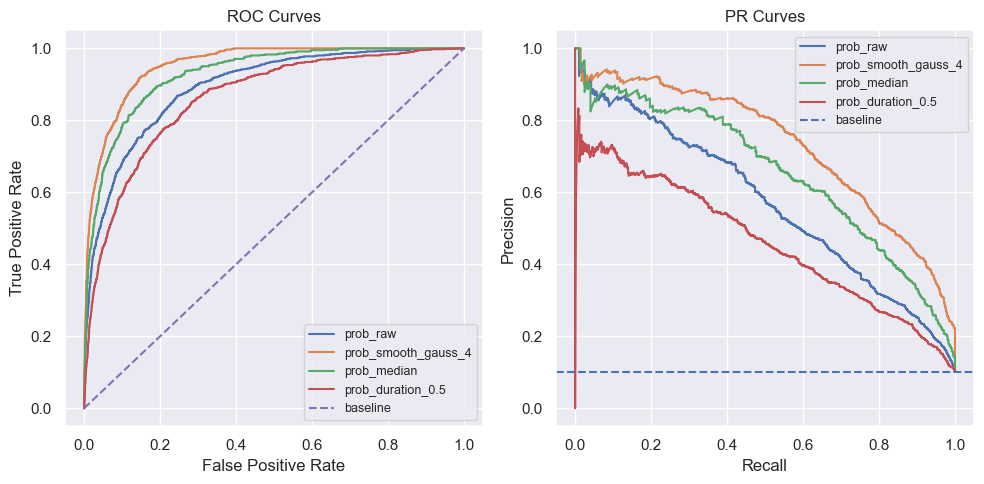

In [ ]:
# PR/ROC curves
cols = ["prob_raw", "prob_smooth_gauss_4", "prob_median", "prob_duration_0.5", "prob_no_fe_2_to_1"]
y_true = df["true"]
df["prob_no_fe_2_to_1"] = probs_base[1:-1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

for col in cols:
    y_score = df[col]

    # ---- ROC ----
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = roc_auc_score(y_true, y_score)
    ax1.plot(fpr, tpr, label=f"{col}")

    # ---- PR ----
    precision, recall, _ = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)
    ax2.plot(recall, precision, label=f"{col}")

# # ---- ROC baseline ----
ax1.plot([0, 1], [0, 1], linestyle="--", label="baseline")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC Curves")
ax1.legend(fontsize=9)

# # ---- PR baseline (positive class prevalence) ----
baseline = y_true.mean()
ax2.axhline(baseline, linestyle="--", label="baseline")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("PR Curves")
ax2.legend(fontsize=9)

plt.tight_layout()
fig.savefig("plots/pres_models/roc_pr_curves.pdf", bbox_inches="tight")

In [37]:
for col in df:
    if col == "true":
        continue
    
    probs = df[col]
    print(col)
    print_all_metrics(df["true"], probs)
    print()

prob_smooth_gauss_1
Accuracy  : 0.92
Precision : 0.66
Recall    : 0.52
F1-score  : 0.58
ROC AUC   : 0.93
PR AUC    : 0.64

prob_smooth_gauss_4
Accuracy  : 0.94
Precision : 0.84
Recall    : 0.45
F1-score  : 0.58
ROC AUC   : 0.95
PR AUC    : 0.73

prob_median
Accuracy  : 0.93
Precision : 0.68
Recall    : 0.52
F1-score  : 0.59
ROC AUC   : 0.93
PR AUC    : 0.66

prob_raw
Accuracy  : 0.91
Precision : 0.54
Recall    : 0.54
F1-score  : 0.54
ROC AUC   : 0.89
PR AUC    : 0.57

prob_duration
Accuracy  : 0.91
Precision : 0.68
Recall    : 0.13
F1-score  : 0.22
ROC AUC   : 0.86
PR AUC    : 0.46



#### True test predictions

In [10]:
# Load true test dataset
df_test = pd.read_parquet("../Dataset/embeddings/presidents_test_metadata_camembert-large.parquet")
X_test = np.stack(df_test["embedding"].to_numpy())
X_test

array([[ 7.31243864e-02,  1.51087940e-01,  3.43201667e-01, ...,
         1.49358600e-01, -3.60857956e-02, -5.71150854e-02],
       [ 1.13912344e-01,  7.95032755e-02,  1.06489763e-01, ...,
         2.30763331e-01, -1.11681044e-01, -2.23053336e-01],
       [-3.99891675e-01,  2.17171937e-01,  2.26480827e-01, ...,
         1.23760276e-01,  1.25295907e-01, -4.21054065e-02],
       ...,
       [-3.74694653e-02,  1.42264664e-01,  2.46501222e-01, ...,
         1.26727909e-01, -9.98448860e-03, -3.48990798e-01],
       [-3.23684990e-01,  1.78836226e-01,  2.63020515e-01, ...,
         1.74744928e-04,  1.11757651e-01, -8.05989653e-02],
       [ 1.03843741e-01,  1.86888754e-01,  2.88044363e-01, ...,
         3.62314135e-01, -6.97851852e-02, -1.38824865e-01]],
      shape=(27162, 1024))

In [38]:
X_train, y_train = embeds, classes_pres
X_train_concat, X_test_concat, y_train_concat = expand_train_test(X_train, X_test, y_train, y_test=None, n=1)

In [39]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_concat, y_train_concat)
pd.DataFrame(data={
    "prob_1":np.pad(model.predict_proba(X_train_concat)[:, 1], 1, mode="edge")
}).to_csv("../Dataset/submissions/submission-movie-test.csv", index=False)

#### Transformers

In [ ]:
#probs_bert = pd.read_csv("../Dataset/predictions/presidents_test_pred_head.csv")["prob_1"].values

# True test dataset only 
probs_bert_lstm = pd.read_csv("../Dataset/predictions/presidents_test_smoothed_probs_lstm.csv")

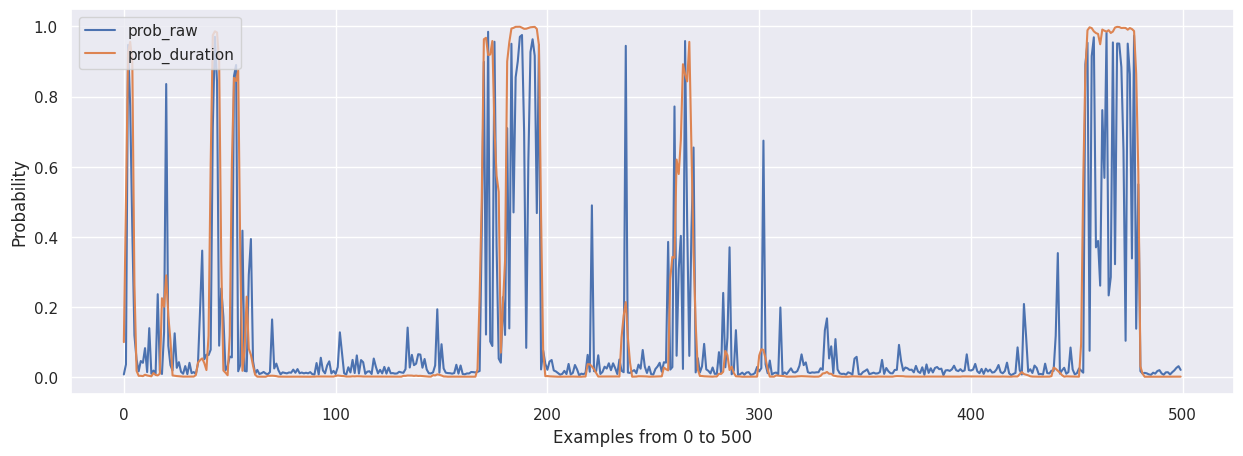

In [58]:
df = pd.DataFrame(data={
    "prob_bert":probs_bert_lstm["base_prob_1"], 
    "probs_bert_lstm":probs_bert_lstm["smoothed_prob_1"]
})

fig=plt.figure(figsize=(15, 5))
mn, mx = 0, 500
#sns.lineplot(df["true"].iloc[mn:mx], label="true")
sns.lineplot(df["prob_bert"].iloc[mn:mx], label="prob_raw")
sns.lineplot(df["probs_bert_lstm"].iloc[mn:mx], label="prob_duration")

plt.xlabel(f"Examples from {mn} to {mx}")
plt.ylabel("Probability")
plt.legend(loc="upper left")
fig.savefig("plots/bert_lstm_smooth.pdf", bbox_inches="tight")